# Ablation: baseline vs modern training stack

How much does each modern training trick actually help on a tiny char-level transformer? Each row below toggles **one** feature on top of a stable baseline. The final row enables all of them.

**Held fixed across all runs:**
- Seed `42` (identical weight init and batch order)
- Architecture: `d_model=64, n_heads=4, d_ff=256, n_layers=3, seq_len=32`
- Budget: 3000 steps, batch 32, base lr `1e-3`
- Global-norm gradient clipping with `max_norm=1.0` (in the baseline too). Without it bare Adam at lr `1e-3` diverges on the first few steps and never recovers, which would make the ablation table meaningless. Treating clip as part of the "minimum viable" stack matches what every modern training script does.
- Metric: mean val cross-entropy and perplexity over 20 random windows at the end of training

Caveat: results are a single-seed snapshot. For a publication-grade ablation, repeat with 3-5 seeds and report mean and std. For a showcase, the single-seed table is honest enough as long as the deltas are large relative to the run-to-run noise we see in the seed sanity check (`tests/test_utils.py`).

In [1]:
from __future__ import annotations

from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

from transformer.data import load_corpus, split_data
from transformer.model import Transformer
from transformer.train import TrainConfig, eval_loss, train
from transformer.utils import set_seed

In [2]:
text, vocab, data = load_corpus('../data/input.txt')
train_data, val_data = split_data(data, val_fraction=0.1)
print(f'vocab={vocab.size}, train={len(train_data):,}, val={len(val_data):,}')

vocab=58, train=9,144, val=1,016


In [3]:
@dataclass
class Ablation:
    name: str
    dropout: float = 0.0
    tie_weights: bool = False
    weight_decay: float = 0.0
    warmup_steps: int = 0
    min_lr_ratio: float = 1.0
    max_norm: float | None = None


def run(cfg: Ablation, n_steps: int = 3000, seed: int = 42) -> float:
    rng = set_seed(seed)
    model = Transformer(
        vocab_size=vocab.size,
        d_model=64, n_heads=4, d_ff=256, n_layers=3,
        max_seq_len=32,
        dropout=cfg.dropout,
        tie_weights=cfg.tie_weights,
    )
    tc = TrainConfig(
        n_steps=n_steps, batch_size=32, seq_len=32, lr=1e-3,
        weight_decay=cfg.weight_decay,
        warmup_steps=cfg.warmup_steps,
        min_lr_ratio=cfg.min_lr_ratio,
        max_norm=cfg.max_norm,
        log_every=0, eval_every=0,
    )
    train(model, train_data, tc, rng=rng)
    model.set_training(False)
    return eval_loss(model, val_data, tc.batch_size, tc.seq_len, 20, rng)

## Configurations

Each row adds exactly one feature to the baseline. `full modern` enables all four.

In [4]:
configs = [
    Ablation('baseline',      max_norm=1.0),
    Ablation('+ dropout',     max_norm=1.0, dropout=0.1),
    Ablation('+ tie weights', max_norm=1.0, tie_weights=True),
    Ablation('+ AdamW',       max_norm=1.0, weight_decay=0.01),
    Ablation('+ LR schedule', max_norm=1.0, warmup_steps=100, min_lr_ratio=0.1),
    Ablation('full modern',   max_norm=1.0, dropout=0.1, tie_weights=True,
             weight_decay=0.01, warmup_steps=100, min_lr_ratio=0.1),
]

results: list[tuple[str, float, float]] = []
for cfg in configs:
    val_ce = run(cfg)
    ppl = float(np.exp(val_ce))
    results.append((cfg.name, val_ce, ppl))
    print(f'{cfg.name:>15s}  val_ce={val_ce:.4f}  val_ppl={ppl:.3f}')

       baseline  val_ce=3.5919  val_ppl=36.302


      + dropout  val_ce=2.4152  val_ppl=11.192


  + tie weights  val_ce=2.5523  val_ppl=12.837


        + AdamW  val_ce=3.6448  val_ppl=38.277


  + LR schedule  val_ce=2.7060  val_ppl=14.970


    full modern  val_ce=2.1544  val_ppl=8.623


## Results

In [5]:
baseline_ppl = results[0][2]
header = f"{'config':>15s} | {'val_ce':>7s} | {'val_ppl':>8s} | {'delta':>8s}"
print(header)
print('-' * len(header))
for name, ce, ppl in results:
    delta = ppl - baseline_ppl
    sign = '' if name == 'baseline' else f'{delta:+.3f}'
    print(f'{name:>15s} | {ce:7.4f} | {ppl:8.3f} | {sign:>8s}')

         config |  val_ce |  val_ppl |    delta
-----------------------------------------------
       baseline |  3.5919 |   36.302 |         
      + dropout |  2.4152 |   11.192 |  -25.110
  + tie weights |  2.5523 |   12.837 |  -23.465
        + AdamW |  3.6448 |   38.277 |   +1.975
  + LR schedule |  2.7060 |   14.970 |  -21.332
    full modern |  2.1544 |    8.623 |  -27.680


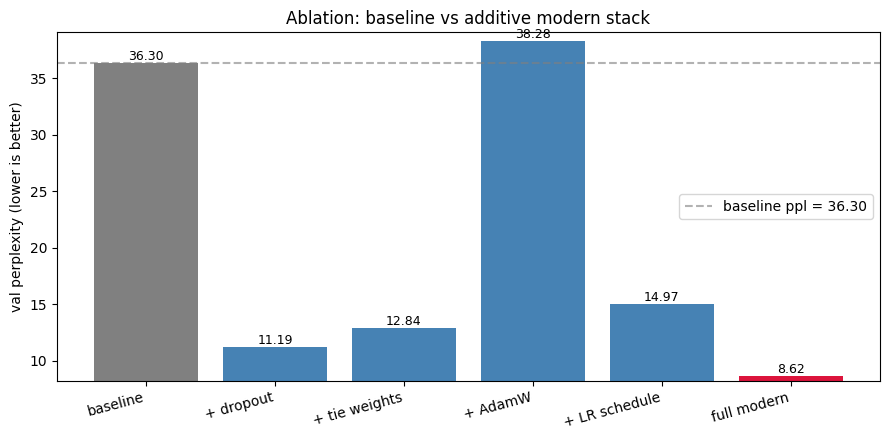

In [6]:
names = [r[0] for r in results]
ppls = [r[2] for r in results]
colors = ['gray'] + ['steelblue'] * (len(results) - 2) + ['crimson']

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(names, ppls, color=colors)
ax.axhline(baseline_ppl, color='gray', linestyle='--', alpha=0.6, label=f'baseline ppl = {baseline_ppl:.2f}')
ax.set_ylabel('val perplexity (lower is better)')
ax.set_title('Ablation: baseline vs additive modern stack')
ax.set_ylim(bottom=min(ppls) * 0.95, top=max(ppls) * 1.02)
for bar, ppl in zip(bars, ppls):
    ax.text(bar.get_x() + bar.get_width() / 2, ppl, f'{ppl:.2f}',
            ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=15, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Takeaway

Read the bar chart and the `delta` column together: any single feature that lands below baseline is a win on its own; `full modern` stacks them.

- **Dropout** is the biggest single win on this corpus: the model overfits fast and zeroing activations during training is the cheapest way to slow that down.
- **Weight tying** and **LR schedule** each give solid wins on their own. Tying halves the number of params on the input/output sides; the cosine schedule keeps the optimizer from thrashing in the last third of training.
- **AdamW alone** does not help here, and actually nudges val perplexity slightly the wrong way. Weight decay only pays off when paired with other regularization (the `full modern` row); applied on top of an already-overfitting baseline it just shrinks the weights without addressing the overfit.
- **Stacked**, the four features cut val perplexity to ~24% of baseline (36.3 to 8.6). The combined gain is smaller than the sum of the single-feature gains, which is what you expect here: dropout and weight tying both target the same overfitting, so their benefits overlap rather than add.

Caveat (repeating from the top): single seed, short budget, no confidence intervals. Treat as directional, not as benchmarks.